In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import gpplot as gpp
from scipy.stats import normaltest
from cycler import cycler

gpp.set_aesthetics(context = 'paper')

Identifying False Negative Rate of detection of essential genes among guide picks from various CRISPRko Cas9 libraries

To retrieve guide mappings in GENCODE 47, guide sequences are inserted into the GPP Internal LIMS tool.


Updated 10/06/2025 to include Jacquere at 4 guides per gene and VBC top 3 selections

In [2]:
path_to_annotations="../Data/GENCODE47 Mappings of CRISPRko Cas9 Genome Wide Libraries/"

## GeCKO v2 (2014)
6 guides/gene

In [3]:
gecko_a=pd.read_csv(path_to_annotations+"gecko_a_adhoc_sgRNA_disco_GRCh38_Ensembl_SpyoCas9Ko_strict.csv")
gecko_b=pd.read_csv(path_to_annotations+"gecko_b_adhoc_sgRNA_disco_GRCh38_Ensembl_SpyoCas9Ko_strict.csv")
gecko=pd.concat([gecko_a,gecko_b])
gecko_guides= gecko["Target Sequence"].tolist()

## Avana (2016)
4 guides/gene screened for DepMap. Downloaded from [DepMap](https://depmap.org/portal/data_page/?tab=allData&releasename=DepMap+Public+24Q4&filename=AvanaGuideMap.csv)

In [4]:
avana=pd.read_csv(path_to_annotations+"avana_adhoc_sgRNA_disco_GRCh38_Ensembl_SpyoCas9Ko_strict.csv")
avana_guides= avana["Target Sequence"].tolist()

## Brunello (2016)


In [5]:
brunello=pd.read_csv(path_to_annotations+"brunello_adhoc_sgRNA_disco_GRCh38_Ensembl_SpyoCas9Ko_strict.csv")
brunello_guides= brunello["Target Sequence"].tolist()

## Human Sanger Genome Wide Library v1 (2016)

human genome-wide CRISPR library (v1) consisting of 90,709 gRNAs targeting a total of 18,010 genes 

from [Tzelepis 2016](https://pmc.ncbi.nlm.nih.gov/articles/PMC5081405/#mmc2)

used for [Project Score](https://score.depmap.sanger.ac.uk/documentation) 

note: I manually curated the hsangerv1.csv file from the MinLibCas9 github MasterLib_v1 [file](https://github.com/EmanuelGoncalves/crispy/blob/master/notebooks/minlib/libraries/MasterLib_v1.csv.gz) to be 20 nt long

In [6]:
hsangerv1=pd.read_csv(path_to_annotations+"hsangerv1_adhoc_sgRNA_disco_GRCh38_Ensembl_SpyoCas9Ko_strict.csv")
hsangerv1_guides= hsangerv1["Target Sequence"].tolist()

## TKOv3 (2017)
[TKOv3 Library Introduction](https://academic.oup.com/g3journal/article/7/8/2719/6031511?login=true)
70,948 gRNAs targeting 18,053 protein-coding genes (up to 4 sgRNA/gene)

In [7]:
tkov3=pd.read_csv(path_to_annotations+"tkov3_adhoc_sgRNA_disco_GRCh38_Ensembl_SpyoCas9Ko_strict.csv")
tkov3_guides= tkov3["Target Sequence"].tolist()

## Gattinara (2018)

In [8]:
gattinara=pd.read_csv(path_to_annotations+"gattinara_adhoc_sgRNA_disco_GRCh38_Ensembl_SpyoCas9Ko_strict.csv")
gattinara_guides= gattinara["Target Sequence"].tolist()

## VBC (2020)
Represents the top 6 guide picks with the highest VBC scores, downloaded from vbc-score.org

In [9]:
vbc=pd.read_csv(path_to_annotations+"vbc_adhoc_sgRNA_disco_GRCh38_Ensembl_SpyoCas9Ko_strict.csv")
vbc_guides= vbc["Target Sequence"].tolist()

In [10]:
vbc_source_annotation=pd.read_table("../Data/Original Annotations of CRISPRko Cas9 Genome Wide Libraries/vbc_hg38_top6_sgRNAs.txt")
vbc_top3=vbc_source_annotation[vbc_source_annotation["Auto-pick top sgRNAs"].isin([1,2,3])]
vbc_top3guides=vbc_top3["sgRNA 20nt"].tolist()

Double checking that "vienna single" is indeed the top 3 VBC picks as stated in Lukasiak 2025

vienna-single-library.txt downloaded from Lukasiak 2025 zenodo. 

In [11]:
vienna_single=pd.read_table("../Data/Lukasiak 2025/vienna-single-library.txt")
vienna_single

,CODE,GENES,SEQ,EXONE,CHRM,STRAND,STARTpos,ENDpos
0,Vienna-A1BG-1,A1BG,GAAGTCCACTCCACTCAG,.,19,+,58351571,58351601
1,Vienna-A1BG-2,A1BG,TCGAGCTGATTCTGAGCGA,.,19,-,58351386,58351416
2,Vienna-A1BG-3,A1BG,CTCCGGGCGACGTGGAGTG,.,19,-,58347595,58347625
3,Vienna-A1CF-1,A1CF,CAGATAAAACCAAAAACCG,.,10,-,50836135,50836165
4,Vienna-A1CF-2,A1CF,CTAGGGTGACTTCAATGG,.,10,+,50816239,50816269
...,...,...,...,...,...,...,...,...
57516,Control_v3_CTRL00496,Control,TAGTTTATTTCCGTATCGC,.,.,.,.,.
57517,Control_v3_CTRL00497,Control,GTAGGAATCTAGAACTCGG,.,.,.,.,.
57518,Control_v3_CTRL00498,Control,ACGCGTCATAGCGGATAAA,.,.,.,.,.
57519,Control_v3_CTRL00499,Control,GCCTAACCCACATAAGCGG,.,.,.,.,.


In [12]:
vienna_single["Position"]=vienna_single.apply(lambda x: "chr"+x["CHRM"]+":"+x["STARTpos"]+"-"+x["ENDpos"]+"("+x["STRAND"]+")",axis=1)
vienna_targeting=vienna_single[vienna_single["GENES"]!="Control"]
vienna_single_only_pos=[pos for pos in vienna_targeting["Position"].tolist() if pos not in vbc_top3["Position"].tolist()]

In [13]:
vbcscores_only_pos=[pos for pos in vbc_top3["Position"].tolist() if pos not in vienna_targeting["Position"].tolist()]

In [14]:
vienna_single[vienna_single["Position"].isin(vienna_single_only_pos)]

,CODE,GENES,SEQ,EXONE,CHRM,STRAND,STARTpos,ENDpos,Position
37612,Vienna-POTEB3-1,POTEB3,TAAAAGAAAAACTTCTAA,.,15,-,136219,136249,chr15:136219-136249(-)
38523,Vienna-PRODH-2,PRODH,CTGTCCAAAGTACACCTGG,.,22,+,138774,138804,chr22:138774-138804(+)


In [15]:
vbc_top3[vbc_top3["Position"].isin(vbcscores_only_pos)]

,gene,sgRNA,Position,Exon number refGene,Auto-pick top sgRNAs,VBC score,Distance TSS=0 stop=1,sgRNA activity 0=bad 1=good,Frameshift ratio inDelphi,Bioscore 0=bad 1=good,...,alias gene names,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,Unnamed: 26,Unnamed: 27,Unnamed: 28,Unnamed: 29,sgRNA 20nt
3820,AMY1C,TGATAATGGGAGCAACCAAGTGG,chr1:103662935-103662965(+),exon 10,3,0.684,0.841,0.856,0.785,0.424,...,"['00000187733', 'ENSG00000187733', '278', 'amy...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TGATAATGGGAGCAACCAAG
4196,ANKRD20A4,CATTCAGCCTAGCACTGAAGTGG,chr9:64397665-64397695(+),exon 11,1,0.519,0.412,0.489,0.736,0.400,...,"['00000172014', 'ENSG00000172014', '728747', '...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CATTCAGCCTAGCACTGAAG
4197,ANKRD20A4,GTATAGTGAGAGCACCTCACTGG,chr9:64373563-64373593(+),exon 3,2,0.731,0.177,0.858,0.916,0.481,...,"['00000172014', 'ENSG00000172014', '728747', '...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,GTATAGTGAGAGCACCTCAC
9537,BOLA2B,GTTGACGTACGCCTTAGTAAGGG,chr16:29454363-29454393(-),exon 1,2,0.720,0.169,0.768,0.651,0.627,...,"['00000169627', 'ENSG00000169627', '654483', '...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,GTTGACGTACGCCTTAGTAA
9676,BPY2C,TATTATGTGAAACTGTACCCGGG,chrY:22997461-22997491(+),exon 6,3,0.696,0.708,1.000,NaN,0.350,...,"['00000185894', 'ENSG00000185894', '442868', '...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TATTATGTGAAACTGTACCC
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
107488,VCY1B,GATGGGCGCCCCTTACTCAGTGG,chrY:13985885-13985915(+),exon 2,3,0.563,0.907,0.719,0.815,0.267,...,"['00000129862', 'ENSG00000129862', '353513', '...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,GATGGGCGCCCCTTACTCAG
109239,XAGE1E,AAAGTCGGGATCCTACACCTGGG,chrX:52515468-52515498(-),exon 2,2,0.792,0.232,1.132,0.564,0.500,...,[],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,AAAGTCGGGATCCTACACCT
113505,ZNF705B,AGCAAGGAAAAGAGCTGTGGTGG,chr8:7950067-7950097(+),exon 5,2,0.632,0.214,0.510,0.817,0.601,...,"['00000215356,ENSG00000285120', 'ENSG000002153...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,AGCAAGGAAAAGAGCTGTGG
113510,ZNF705D,AGCAAGGAAAAGAGCTGTGGCGG,chr8:12110834-12110864(+),exon 5,1,0.632,0.214,0.563,0.730,0.586,...,"['00000215343', 'ENSG00000215343', '728957', '...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,AGCAAGGAAAAGAGCTGTGG


There are just 288 guides selected by the top 3 VBC scores that are not in the list of sgRNAs in Vienna single that you can find in the Lukasiak 2025 zenodo , but they use CRISPR CleanR in their analysis which filters out underrepresented sgRNAs (those with <30 counts in the pDNA, so this likely explains the discrepancy. 

## MinLibCas9 (2021)
[source: Goncalves et al 2021](https://genomebiology.biomedcentral.com/articles/10.1186/s13059-021-02268-4#Sec15)
covers 18,761 protein-coding genes with 37,522 sgRNAs (33,986 Project Score; 1732 Brunello; 1493 Avana and 311 TKOv3). Preferentially selected guides with demonstrated activity in Project Score data.

In [16]:
minlibcas9=pd.read_csv(path_to_annotations+"minlibcas9_adhoc_sgRNA_disco_GRCh38_Ensembl_SpyoCas9Ko_strict.csv")
minlibcas9_guides= minlibcas9["Target Sequence"].tolist()

## Jacquere (2025)

In [17]:
jacquere= pd.read_csv(path_to_annotations+"jacquere_quota3_adhoc_sgRNA_disco_GRCh38_Ensembl_SpyoCas9Ko_strict.csv")
jacquere_guides= jacquere["Target Sequence"].tolist()

In [18]:
jacquere_allpicks= pd.read_csv("../../4. Jacquere Design/Data/Jacquere_PerTargetAnnotations_uptoquota4.csv")
jacquere_4guides=jacquere_allpicks["sgRNA Sequence"].tolist()
jacquere_2guides=jacquere_allpicks[jacquere_allpicks["Pick Order"].isin([1,2])]["sgRNA Sequence"].tolist()

# Get False Negative Rates from DeWeirdt 2022 tiling

In [19]:
rs3val_zscores= pd.read_csv("../../2. Developing promiscuous classifier/Data/rs3valdata_updatedmappings_zscore.csv")
rs3val_zscores

,Unnamed: 0,sgRNA Sequence,sgRNA_lfc,Target Sequence,On-target Gene Symbols,Notes,noness_targeting,z_scored_sgRNA_lfc
0,0,AAAAAAAAGCACTGTCATGC,1.551436,AAAAAAAAGCACTGTCATGC,C8orf17,NaN,False,1.801807
1,1,AAAAAAAGCACTGTCATGCA,0.879857,AAAAAAAGCACTGTCATGCA,C8orf17,NaN,False,0.583091
2,2,AAAAAAAGGGAGGACCACTG,-0.717881,AAAAAAAGGGAGGACCACTG,WDR55,NaN,False,-2.316328
3,3,AAAAAAAGGGCTGCCCCAAA,-0.537565,AAAAAAAGGGCTGCCCCAAA,TOP2A,NaN,False,-1.989108
4,4,AAAAAAAGTAGTGTGAAGTC,-0.790484,AAAAAAAGTAGTGTGAAGTC,LUC7L3,NaN,False,-2.448081
...,...,...,...,...,...,...,...,...
84340,84340,TTTGTTGTATGATAAACATC,-1.194462,TTTGTTGTATGATAAACATC,UPF2,NaN,False,-3.181181
84341,84341,TTTGTTTCAGACTTTGTTTC,0.859021,TTTGTTTCAGACTTTGTTTC,ITGAV,NaN,False,0.545279
84342,84342,TTTGTTTCTCAGGACCGCAT,-3.089690,TTTGTTTCTCAGGACCGCAT,DDB1,NaN,False,-6.620457
84343,84343,TTTGTTTCTCTTTCTACAAG,0.684651,TTTGTTTCTCTTTCTACAAG,HEATR1,NaN,False,0.228851


In [20]:
#get essential vs nonessential classifications 

noness_genes = pd.read_csv("../../2. Developing promiscuous classifier/Data/AchillesNonessentialControls.csv")
noness_genes["Gene"]=noness_genes["Gene"].apply(lambda x: x.split("(")[0])
#remove space from gene name 
noness_genes["Gene"]=noness_genes["Gene"].str.replace(" ","")
noness_gene_list=noness_genes["Gene"].tolist()

essential_genes = pd.read_csv("../../2. Developing promiscuous classifier/Data/AchillesCommonEssentialControls.csv")
essential_genes["Gene"]=essential_genes["Gene"].apply(lambda x: x.split("(")[0])
#remove space from gene name 
essential_genes["Gene"]=essential_genes["Gene"].str.replace(" ","")
essential_gene_list=essential_genes["Gene"].tolist()

rs3val_zscores["is_essential"]=rs3val_zscores["On-target Gene Symbols"].isin(essential_gene_list)
rs3val_zscores["is_nonessential"]=rs3val_zscores["On-target Gene Symbols"].isin(noness_gene_list)

print("# essential:",len(rs3val_zscores[rs3val_zscores["is_essential"]]))
print("# nonessential:",len(rs3val_zscores[rs3val_zscores["is_nonessential"]]))

# essential: 31240
# nonessential: 25735


### Merge screen data with libraries

In [21]:
gecko_with_z_scores=rs3val_zscores[rs3val_zscores["sgRNA Sequence"].isin(gecko_guides)].reset_index(drop=True)
gene_avg_z_gecko = (gecko_with_z_scores.groupby(['On-target Gene Symbols',"is_essential","is_nonessential"])
                     .agg(mean_z = ('z_scored_sgRNA_lfc', 'mean'),
                          n_sgrnas = ('z_scored_sgRNA_lfc', 'count'))
                     .reset_index())

avana_with_z_scores=rs3val_zscores[rs3val_zscores["sgRNA Sequence"].isin(avana_guides)].reset_index(drop=True)
gene_avg_z_avana = (avana_with_z_scores.groupby(['On-target Gene Symbols',"is_essential","is_nonessential"])
                     .agg(mean_z = ('z_scored_sgRNA_lfc', 'mean'),
                          n_sgrnas = ('z_scored_sgRNA_lfc', 'count'))
                     .reset_index())

brunello_with_z_scores=rs3val_zscores[rs3val_zscores["sgRNA Sequence"].isin(brunello_guides)].reset_index(drop=True)
gene_avg_z_brunello = (brunello_with_z_scores.groupby(['On-target Gene Symbols',"is_essential","is_nonessential"])
                     .agg(mean_z = ('z_scored_sgRNA_lfc', 'mean'),
                          n_sgrnas = ('z_scored_sgRNA_lfc', 'count'))
                     .reset_index())

hsangerv1_with_z_scores=rs3val_zscores[rs3val_zscores["sgRNA Sequence"].isin(hsangerv1_guides)].reset_index(drop=True)
gene_avg_z_hsangerv1 = (hsangerv1_with_z_scores.groupby(['On-target Gene Symbols',"is_essential","is_nonessential"])
                     .agg(mean_z = ('z_scored_sgRNA_lfc', 'mean'),
                          n_sgrnas = ('z_scored_sgRNA_lfc', 'count'))
                     .reset_index())

tkov3_with_z_scores=rs3val_zscores[rs3val_zscores["sgRNA Sequence"].isin(tkov3_guides)].reset_index(drop=True)
gene_avg_z_tkov3 = (tkov3_with_z_scores.groupby(['On-target Gene Symbols',"is_essential","is_nonessential"])
                     .agg(mean_z = ('z_scored_sgRNA_lfc', 'mean'),
                          n_sgrnas = ('z_scored_sgRNA_lfc', 'count'))
                     .reset_index())


gattinara_with_z_scores=rs3val_zscores[rs3val_zscores["sgRNA Sequence"].isin(gattinara_guides)].reset_index(drop=True)
gene_avg_z_gattinara = (gattinara_with_z_scores.groupby(['On-target Gene Symbols',"is_essential","is_nonessential"])
                     .agg(mean_z = ('z_scored_sgRNA_lfc', 'mean'),
                          n_sgrnas = ('z_scored_sgRNA_lfc', 'count'))
                     .reset_index())

vbc_with_z_scores=rs3val_zscores[rs3val_zscores["sgRNA Sequence"].isin(vbc_guides)].reset_index(drop=True)
gene_avg_z_vbc = (vbc_with_z_scores.groupby(['On-target Gene Symbols',"is_essential","is_nonessential"])
                     .agg(mean_z = ('z_scored_sgRNA_lfc', 'mean'),
                          n_sgrnas = ('z_scored_sgRNA_lfc', 'count'))
                     .reset_index())

vbc_top3_with_z_scores=rs3val_zscores[rs3val_zscores["sgRNA Sequence"].isin(vbc_top3guides)].reset_index(drop=True)
gene_avg_z_vbc_top3 = (vbc_top3_with_z_scores.groupby(['On-target Gene Symbols',"is_essential","is_nonessential"])
                     .agg(mean_z = ('z_scored_sgRNA_lfc', 'mean'),
                          n_sgrnas = ('z_scored_sgRNA_lfc', 'count'))
                     .reset_index())

minlibcas9_with_z_scores=rs3val_zscores[rs3val_zscores["sgRNA Sequence"].isin(minlibcas9_guides)].reset_index(drop=True)
gene_avg_z_minlibcas9 = (minlibcas9_with_z_scores.groupby(['On-target Gene Symbols',"is_essential","is_nonessential"])
                     .agg(mean_z = ('z_scored_sgRNA_lfc', 'mean'),
                          n_sgrnas = ('z_scored_sgRNA_lfc', 'count'))
                     .reset_index())

jacquere4_with_z_scores=rs3val_zscores[rs3val_zscores["sgRNA Sequence"].isin(jacquere_4guides)].reset_index(drop=True)
gene_avg_z_jacquere4 = (jacquere4_with_z_scores.groupby(['On-target Gene Symbols',"is_essential","is_nonessential"])
                     .agg(mean_z = ('z_scored_sgRNA_lfc', 'mean'),
                          n_sgrnas = ('z_scored_sgRNA_lfc', 'count'))
                     .reset_index())

jacquere_with_z_scores=rs3val_zscores[rs3val_zscores["sgRNA Sequence"].isin(jacquere_guides)].reset_index(drop=True)
gene_avg_z_jacquere = (jacquere_with_z_scores.groupby(['On-target Gene Symbols',"is_essential","is_nonessential"])
                     .agg(mean_z = ('z_scored_sgRNA_lfc', 'mean'),
                          n_sgrnas = ('z_scored_sgRNA_lfc', 'count'))
                     .reset_index())

jacquere2_with_z_scores=rs3val_zscores[rs3val_zscores["sgRNA Sequence"].isin(jacquere_2guides)].reset_index(drop=True)
gene_avg_z_jacquere2 = (jacquere2_with_z_scores.groupby(['On-target Gene Symbols',"is_essential","is_nonessential"])
                     .agg(mean_z = ('z_scored_sgRNA_lfc', 'mean'),
                          n_sgrnas = ('z_scored_sgRNA_lfc', 'count'))
                     .reset_index())


Get # essential-targeting guides in each library that exceed z-score cutoff 

In [22]:
gene_avg_z_gecko_essentials=gene_avg_z_gecko[gene_avg_z_gecko["is_essential"]].reset_index(drop=True)
gene_avg_z_gecko_essentials["z<-2"]=gene_avg_z_gecko_essentials["mean_z"]<-2
gene_avg_z_gecko_essentials["z<-3"]=gene_avg_z_gecko_essentials["mean_z"]<-3
gene_avg_z_gecko_essentials["z<-4"]=gene_avg_z_gecko_essentials["mean_z"]<-4
gecko_FNR_zneg2=len(gene_avg_z_gecko_essentials[gene_avg_z_gecko_essentials["z<-2"]==False])/len(gene_avg_z_gecko_essentials)
gecko_FNR_zneg3=len(gene_avg_z_gecko_essentials[gene_avg_z_gecko_essentials["z<-3"]==False])/len(gene_avg_z_gecko_essentials)
gecko_FNR_zneg4=len(gene_avg_z_gecko_essentials[gene_avg_z_gecko_essentials["z<-4"]==False])/len(gene_avg_z_gecko_essentials)


gene_avg_z_avana_essentials=gene_avg_z_avana[gene_avg_z_avana["is_essential"]].reset_index(drop=True)
gene_avg_z_avana_essentials["z<-2"]=gene_avg_z_avana_essentials["mean_z"]<-2
gene_avg_z_avana_essentials["z<-3"]=gene_avg_z_avana_essentials["mean_z"]<-3
gene_avg_z_avana_essentials["z<-4"]=gene_avg_z_avana_essentials["mean_z"]<-4
avana_FNR_zneg2=len(gene_avg_z_avana_essentials[gene_avg_z_avana_essentials["z<-2"]==False])/len(gene_avg_z_avana_essentials)
avana_FNR_zneg3=len(gene_avg_z_avana_essentials[gene_avg_z_avana_essentials["z<-3"]==False])/len(gene_avg_z_avana_essentials)
avana_FNR_zneg4=len(gene_avg_z_avana_essentials[gene_avg_z_avana_essentials["z<-4"]==False])/len(gene_avg_z_avana_essentials)

gene_avg_z_hsangerv1_essentials=gene_avg_z_hsangerv1[gene_avg_z_hsangerv1["is_essential"]].reset_index(drop=True)
gene_avg_z_hsangerv1_essentials["z<-2"]=gene_avg_z_hsangerv1_essentials["mean_z"]<-2
gene_avg_z_hsangerv1_essentials["z<-3"]=gene_avg_z_hsangerv1_essentials["mean_z"]<-3
gene_avg_z_hsangerv1_essentials["z<-4"]=gene_avg_z_hsangerv1_essentials["mean_z"]<-4
hsangerv1_FNR_zneg2=len(gene_avg_z_hsangerv1_essentials[gene_avg_z_hsangerv1_essentials["z<-2"]==False])/len(gene_avg_z_hsangerv1_essentials)
hsangerv1_FNR_zneg3=len(gene_avg_z_hsangerv1_essentials[gene_avg_z_hsangerv1_essentials["z<-3"]==False])/len(gene_avg_z_hsangerv1_essentials)
hsangerv1_FNR_zneg4=len(gene_avg_z_hsangerv1_essentials[gene_avg_z_hsangerv1_essentials["z<-4"]==False])/len(gene_avg_z_hsangerv1_essentials)


gene_avg_z_brunello_essentials=gene_avg_z_brunello[gene_avg_z_brunello["is_essential"]].reset_index(drop=True)
gene_avg_z_brunello_essentials["z<-2"]=gene_avg_z_brunello_essentials["mean_z"]<-2
gene_avg_z_brunello_essentials["z<-3"]=gene_avg_z_brunello_essentials["mean_z"]<-3
gene_avg_z_brunello_essentials["z<-4"]=gene_avg_z_brunello_essentials["mean_z"]<-4
brunello_FNR_zneg2=len(gene_avg_z_brunello_essentials[gene_avg_z_brunello_essentials["z<-2"]==False])/len(gene_avg_z_brunello_essentials)
brunello_FNR_zneg3=len(gene_avg_z_brunello_essentials[gene_avg_z_brunello_essentials["z<-3"]==False])/len(gene_avg_z_brunello_essentials)
brunello_FNR_zneg4=len(gene_avg_z_brunello_essentials[gene_avg_z_brunello_essentials["z<-4"]==False])/len(gene_avg_z_brunello_essentials)

gene_avg_z_tkov3_essentials=gene_avg_z_tkov3[gene_avg_z_tkov3["is_essential"]].reset_index(drop=True)
gene_avg_z_tkov3_essentials["z<-2"]=gene_avg_z_tkov3_essentials["mean_z"]<-2
gene_avg_z_tkov3_essentials["z<-3"]=gene_avg_z_tkov3_essentials["mean_z"]<-3
gene_avg_z_tkov3_essentials["z<-4"]=gene_avg_z_tkov3_essentials["mean_z"]<-4
tkov3_FNR_zneg2=len(gene_avg_z_tkov3_essentials[gene_avg_z_tkov3_essentials["z<-2"]==False])/len(gene_avg_z_tkov3_essentials)
tkov3_FNR_zneg3=len(gene_avg_z_tkov3_essentials[gene_avg_z_tkov3_essentials["z<-3"]==False])/len(gene_avg_z_tkov3_essentials)
tkov3_FNR_zneg4=len(gene_avg_z_tkov3_essentials[gene_avg_z_tkov3_essentials["z<-4"]==False])/len(gene_avg_z_tkov3_essentials)

gene_avg_z_gattinara_essentials=gene_avg_z_gattinara[gene_avg_z_gattinara["is_essential"]].reset_index(drop=True)
gene_avg_z_gattinara_essentials["z<-2"]=gene_avg_z_gattinara_essentials["mean_z"]<-2
gene_avg_z_gattinara_essentials["z<-3"]=gene_avg_z_gattinara_essentials["mean_z"]<-3
gene_avg_z_gattinara_essentials["z<-4"]=gene_avg_z_gattinara_essentials["mean_z"]<-4
gattinara_FNR_zneg2=len(gene_avg_z_gattinara_essentials[gene_avg_z_gattinara_essentials["z<-2"]==False])/len(gene_avg_z_gattinara_essentials)
gattinara_FNR_zneg3=len(gene_avg_z_gattinara_essentials[gene_avg_z_gattinara_essentials["z<-3"]==False])/len(gene_avg_z_gattinara_essentials)
gattinara_FNR_zneg4=len(gene_avg_z_gattinara_essentials[gene_avg_z_gattinara_essentials["z<-4"]==False])/len(gene_avg_z_gattinara_essentials)

gene_avg_z_vbc_essentials=gene_avg_z_vbc[gene_avg_z_vbc["is_essential"]].reset_index(drop=True)
gene_avg_z_vbc_essentials["z<-2"]=gene_avg_z_vbc_essentials["mean_z"]<-2
gene_avg_z_vbc_essentials["z<-3"]=gene_avg_z_vbc_essentials["mean_z"]<-3
gene_avg_z_vbc_essentials["z<-4"]=gene_avg_z_vbc_essentials["mean_z"]<-4
vbc_FNR_zneg2=len(gene_avg_z_vbc_essentials[gene_avg_z_vbc_essentials["z<-2"]==False])/len(gene_avg_z_vbc_essentials)
vbc_FNR_zneg3=len(gene_avg_z_vbc_essentials[gene_avg_z_vbc_essentials["z<-3"]==False])/len(gene_avg_z_vbc_essentials)
vbc_FNR_zneg4=len(gene_avg_z_vbc_essentials[gene_avg_z_vbc_essentials["z<-4"]==False])/len(gene_avg_z_vbc_essentials)

gene_avg_z_vbc_top3_essentials=gene_avg_z_vbc_top3[gene_avg_z_vbc_top3["is_essential"]].reset_index(drop=True)
gene_avg_z_vbc_top3_essentials["z<-2"]=gene_avg_z_vbc_top3_essentials["mean_z"]<-2
gene_avg_z_vbc_top3_essentials["z<-3"]=gene_avg_z_vbc_top3_essentials["mean_z"]<-3
gene_avg_z_vbc_top3_essentials["z<-4"]=gene_avg_z_vbc_top3_essentials["mean_z"]<-4
vbc_top3_FNR_zneg2=len(gene_avg_z_vbc_top3_essentials[gene_avg_z_vbc_top3_essentials["z<-2"]==False])/len(gene_avg_z_vbc_top3_essentials)
vbc_top3_FNR_zneg3=len(gene_avg_z_vbc_top3_essentials[gene_avg_z_vbc_top3_essentials["z<-3"]==False])/len(gene_avg_z_vbc_top3_essentials)
vbc_top3_FNR_zneg4=len(gene_avg_z_vbc_top3_essentials[gene_avg_z_vbc_top3_essentials["z<-4"]==False])/len(gene_avg_z_vbc_top3_essentials)


gene_avg_z_minlibcas9_essentials=gene_avg_z_minlibcas9[gene_avg_z_minlibcas9["is_essential"]].reset_index(drop=True)
gene_avg_z_minlibcas9_essentials["z<-2"]=gene_avg_z_minlibcas9_essentials["mean_z"]<-2
gene_avg_z_minlibcas9_essentials["z<-3"]=gene_avg_z_minlibcas9_essentials["mean_z"]<-3
gene_avg_z_minlibcas9_essentials["z<-4"]=gene_avg_z_minlibcas9_essentials["mean_z"]<-4
minlibcas9_FNR_zneg2=len(gene_avg_z_minlibcas9_essentials[gene_avg_z_minlibcas9_essentials["z<-2"]==False])/len(gene_avg_z_minlibcas9_essentials)
minlibcas9_FNR_zneg3=len(gene_avg_z_minlibcas9_essentials[gene_avg_z_minlibcas9_essentials["z<-3"]==False])/len(gene_avg_z_minlibcas9_essentials)
minlibcas9_FNR_zneg4=len(gene_avg_z_minlibcas9_essentials[gene_avg_z_minlibcas9_essentials["z<-4"]==False])/len(gene_avg_z_minlibcas9_essentials)

gene_avg_z_jacquere4_essentials=gene_avg_z_jacquere4[gene_avg_z_jacquere4["is_essential"]].reset_index(drop=True)
gene_avg_z_jacquere4_essentials["z<-2"]=gene_avg_z_jacquere4_essentials["mean_z"]<-2
gene_avg_z_jacquere4_essentials["z<-3"]=gene_avg_z_jacquere4_essentials["mean_z"]<-3
gene_avg_z_jacquere4_essentials["z<-4"]=gene_avg_z_jacquere4_essentials["mean_z"]<-4
jacquere4_FNR_zneg2=len(gene_avg_z_jacquere4_essentials[gene_avg_z_jacquere4_essentials["z<-2"]==False])/len(gene_avg_z_jacquere4_essentials)
jacquere4_FNR_zneg3=len(gene_avg_z_jacquere4_essentials[gene_avg_z_jacquere4_essentials["z<-3"]==False])/len(gene_avg_z_jacquere4_essentials)
jacquere4_FNR_zneg4=len(gene_avg_z_jacquere4_essentials[gene_avg_z_jacquere4_essentials["z<-4"]==False])/len(gene_avg_z_jacquere4_essentials)

gene_avg_z_jacquere_essentials=gene_avg_z_jacquere[gene_avg_z_jacquere["is_essential"]].reset_index(drop=True)
gene_avg_z_jacquere_essentials["z<-2"]=gene_avg_z_jacquere_essentials["mean_z"]<-2
gene_avg_z_jacquere_essentials["z<-3"]=gene_avg_z_jacquere_essentials["mean_z"]<-3
gene_avg_z_jacquere_essentials["z<-4"]=gene_avg_z_jacquere_essentials["mean_z"]<-4
jacquere_FNR_zneg2=len(gene_avg_z_jacquere_essentials[gene_avg_z_jacquere_essentials["z<-2"]==False])/len(gene_avg_z_jacquere_essentials)
jacquere_FNR_zneg3=len(gene_avg_z_jacquere_essentials[gene_avg_z_jacquere_essentials["z<-3"]==False])/len(gene_avg_z_jacquere_essentials)
jacquere_FNR_zneg4=len(gene_avg_z_jacquere_essentials[gene_avg_z_jacquere_essentials["z<-4"]==False])/len(gene_avg_z_jacquere_essentials)

gene_avg_z_jacquere2_essentials=gene_avg_z_jacquere2[gene_avg_z_jacquere2["is_essential"]].reset_index(drop=True)
gene_avg_z_jacquere2_essentials["z<-2"]=gene_avg_z_jacquere2_essentials["mean_z"]<-2
gene_avg_z_jacquere2_essentials["z<-3"]=gene_avg_z_jacquere2_essentials["mean_z"]<-3
gene_avg_z_jacquere2_essentials["z<-4"]=gene_avg_z_jacquere2_essentials["mean_z"]<-4
jacquere2_FNR_zneg2=len(gene_avg_z_jacquere2_essentials[gene_avg_z_jacquere2_essentials["z<-2"]==False])/len(gene_avg_z_jacquere2_essentials)
jacquere2_FNR_zneg3=len(gene_avg_z_jacquere2_essentials[gene_avg_z_jacquere2_essentials["z<-3"]==False])/len(gene_avg_z_jacquere2_essentials)
jacquere2_FNR_zneg4=len(gene_avg_z_jacquere2_essentials[gene_avg_z_jacquere2_essentials["z<-4"]==False])/len(gene_avg_z_jacquere2_essentials)



In [23]:
library_labels=["GeCKOv2 : 6",
                "Avana : 4",
                "Brunello : 4",
                "Proj.Score : 5",
                "TKOv3 : 4",
                "Gattinara : 2",
                "VBC : 6",
                "VBC: 3",
                "MinLib2 : 2",
                "Jacquere : 4",
                "Jacquere : 3",
               "Jacquere : 2"]
FNR_df=pd.DataFrame({"Z<-2":[gecko_FNR_zneg2,avana_FNR_zneg2,brunello_FNR_zneg2,hsangerv1_FNR_zneg2,tkov3_FNR_zneg2,gattinara_FNR_zneg2,vbc_FNR_zneg2,vbc_top3_FNR_zneg2,minlibcas9_FNR_zneg2,jacquere4_FNR_zneg2,jacquere_FNR_zneg2,jacquere2_FNR_zneg2],
             "Z<-3":[gecko_FNR_zneg3,avana_FNR_zneg3,brunello_FNR_zneg3,hsangerv1_FNR_zneg3,tkov3_FNR_zneg3,gattinara_FNR_zneg3,vbc_FNR_zneg3,vbc_top3_FNR_zneg3,minlibcas9_FNR_zneg3,jacquere4_FNR_zneg3,jacquere_FNR_zneg3,jacquere2_FNR_zneg3],
              "Z<-4":[gecko_FNR_zneg4,avana_FNR_zneg4,brunello_FNR_zneg4,hsangerv1_FNR_zneg4,tkov3_FNR_zneg4,gattinara_FNR_zneg4,vbc_FNR_zneg4,vbc_top3_FNR_zneg4,minlibcas9_FNR_zneg4,jacquere4_FNR_zneg4,jacquere_FNR_zneg4,jacquere2_FNR_zneg4]
             },index=library_labels)
FNR_df=FNR_df.multiply(100).astype(int) #convert decimals to percentages
FNR_df

,Z<-2,Z<-3,Z<-4
GeCKOv2 : 6,9,27,61
Avana : 4,6,27,51
Brunello : 4,8,22,53
Proj.Score : 5,9,21,51
TKOv3 : 4,10,35,57
Gattinara : 2,11,23,49
VBC : 6,4,13,31
VBC: 3,4,14,30
MinLib2 : 2,9,18,40
Jacquere : 4,3,13,33


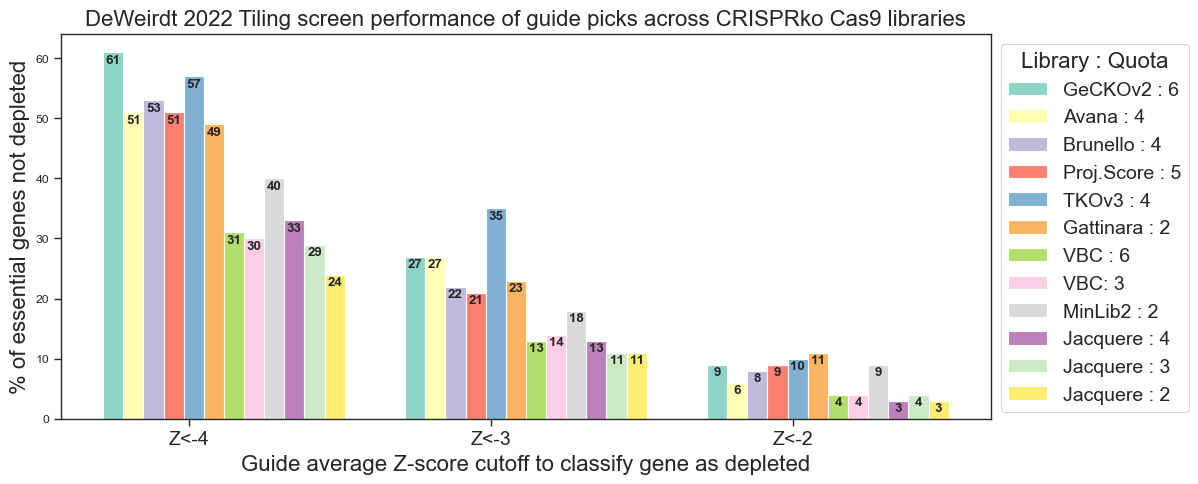

In [24]:
x = np.arange(0,9,3)  # the label locations
width = 0.2  # the width of the bars
multiplier = 0

fig, ax = plt.subplots(figsize=(12,5))
ax.set_prop_cycle(cycler('color', plt.cm.Set3.colors))

for library, zcutoff in FNR_df[["Z<-4","Z<-3","Z<-2"]].transpose().items():
    offset = width * multiplier
    rects = ax.bar(x + offset, zcutoff, width, label=library)
    ax.bar_label(rects, padding=-10,fontweight="bold")
    multiplier += 1

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('% of essential genes not depleted',fontsize=16)
ax.set_xlabel("Guide average Z-score cutoff to classify gene as depleted",fontsize=16)
ax.set_title('DeWeirdt 2022 Tiling screen performance of guide picks across CRISPRko Cas9 libraries',fontsize=16)
ax.set_xticks(x + 0.75,["Z<-4","Z<-3","Z<-2"],fontsize=14)
ax.legend(fontsize=14,title="Library : Quota",title_fontsize=16,bbox_to_anchor = [1, 1])
plt.savefig("../Figures/genomewide_crisprko_cas9_libraries_FNR.pdf",bbox_inches="tight",dpi=600)
